(np.float64(-0.5), np.float64(182.5), np.float64(274.5), np.float64(-0.5))

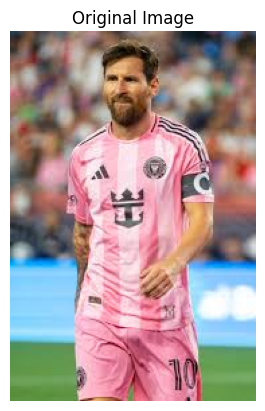

In [10]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as dai

# Đọc ảnh
img = cv.imread('hinh1.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Hiển thị
dai.imshow(img)
dai.title("Original Image")
dai.axis('off')

(np.float64(-0.5), np.float64(182.5), np.float64(274.5), np.float64(-0.5))

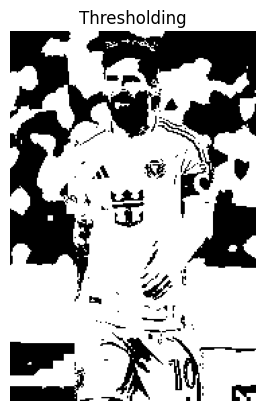

In [3]:
gray = cv.cvtColor(img, cv.COLOR_RGB2GRAY)

_, thresh = cv.threshold(gray, 127, 255, cv.THRESH_BINARY)

dai.imshow(thresh, cmap='gray')
dai.title("Thresholding")
dai.axis('off')

(np.float64(-0.5), np.float64(182.5), np.float64(274.5), np.float64(-0.5))

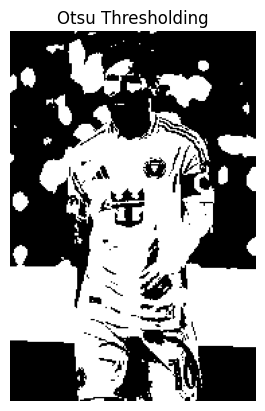

In [4]:
_, otsu = cv.threshold(gray, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

dai.imshow(otsu, cmap='gray')
dai.title("Otsu Thresholding")
dai.axis('off')

(np.float64(-0.5), np.float64(182.5), np.float64(274.5), np.float64(-0.5))

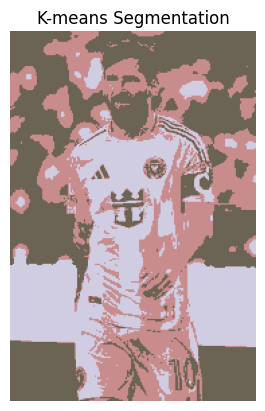

In [5]:
Z = img.reshape((-1, 3))
Z = np.float32(Z)

K = 3
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 10, 1.0)

_, label, center = cv.kmeans(Z, K, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)

center = np.uint8(center)
res = center[label.flatten()]
segmented = res.reshape(img.shape)

dai.imshow(segmented)
dai.title("K-means Segmentation")
dai.axis('off')

(np.float64(-0.5), np.float64(182.5), np.float64(274.5), np.float64(-0.5))

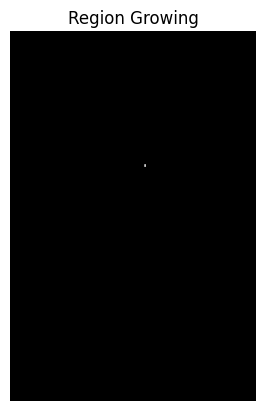

In [6]:
def region_growing(image, seed, threshold=10):
    h, w = image.shape
    visited = np.zeros((h, w), np.uint8)
    result = np.zeros((h, w), np.uint8)

    stack = [seed]
    seed_value = image[seed]

    while stack:
        x, y = stack.pop()
        if visited[x, y] == 0:
            visited[x, y] = 1
            result[x, y] = 255

            for dx, dy in [(-1,0),(1,0),(0,-1),(0,1)]:
                nx, ny = x+dx, y+dy
                if 0 <= nx < h and 0 <= ny < w:
                    if abs(int(image[nx, ny]) - int(seed_value)) < threshold:
                        stack.append((nx, ny))
    return result

rg = region_growing(gray, (100,100))

dai.imshow(rg, cmap='gray')
dai.title("Region Growing")
dai.axis('off')

(np.float64(-0.5), np.float64(182.5), np.float64(274.5), np.float64(-0.5))

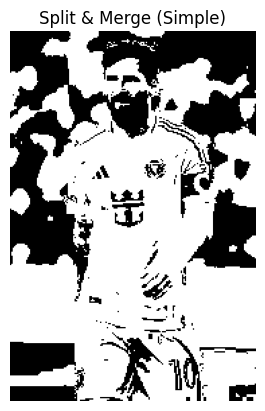

In [7]:
_, split = cv.threshold(gray, 128, 255, cv.THRESH_BINARY)

dai.imshow(split, cmap='gray')
dai.title("Split & Merge (Simple)")
dai.axis('off')

(np.float64(-0.5), np.float64(182.5), np.float64(274.5), np.float64(-0.5))

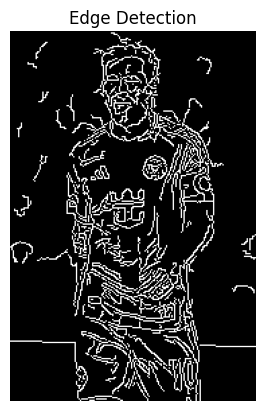

In [8]:
edges = cv.Canny(gray, 100, 200)

dai.imshow(edges, cmap='gray')
dai.title("Edge Detection")
dai.axis('off')